In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from utilsforecast.plotting import plot_series 
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

import warnings
warnings.filterwarnings("ignore")




In [6]:
df = pd.read_csv("https://raw.githubusercontent.com/marcopeix/youtube_tutorials/refs/heads/main/data/daily_sales_french_bakery.csv", parse_dates=["ds"])
df = df.groupby('unique_id').filter(lambda x : len(x) >= 28)
df = df.drop(["unit_price"], axis = 1)
df.head()




,unique_id,ds,y
0,12 MACARON,2022-07-13,10.0
1,12 MACARON,2022-07-14,0.0
2,12 MACARON,2022-07-15,0.0
3,12 MACARON,2022-07-16,10.0
4,12 MACARON,2022-07-17,30.0


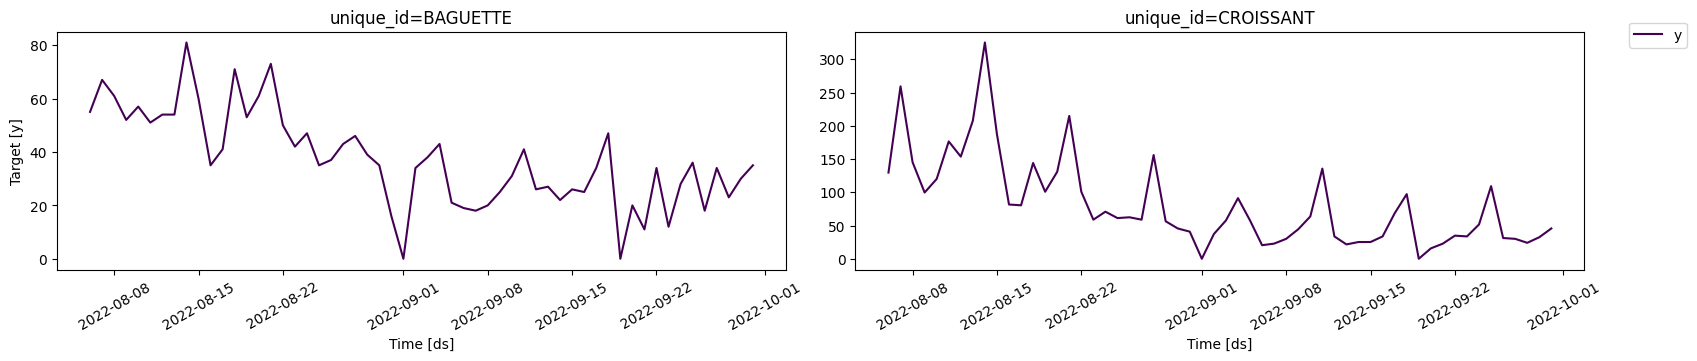

In [7]:
plot_series(df = df, ids=["BAGUETTE", "CROISSANT"], palette = "viridis")
plot_series(df = df , ids=["BAGUETTE", "CROISSANT"] , max_insample_length=56, palette='viridis' )


In [8]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive

In [ ]:
horizon = 7
models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size = 7),
    SeasonalNaive(season_length=7)


]

sf = StatsForecast(models = models, freq="D")
sf.fit(df=df)
preds = sf.predict(h = horizon)

In [22]:
preds.head()

,unique_id,ds,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,12 MACARON,2022-09-29,10.0,8.974359,2.0,0.0
1,12 MACARON,2022-09-30,10.0,8.974359,2.0,0.0
2,12 MACARON,2022-10-01,10.0,8.974359,2.0,0.0
3,12 MACARON,2022-10-02,10.0,8.974359,2.0,0.0
4,12 MACARON,2022-10-03,10.0,8.974359,2.0,0.0


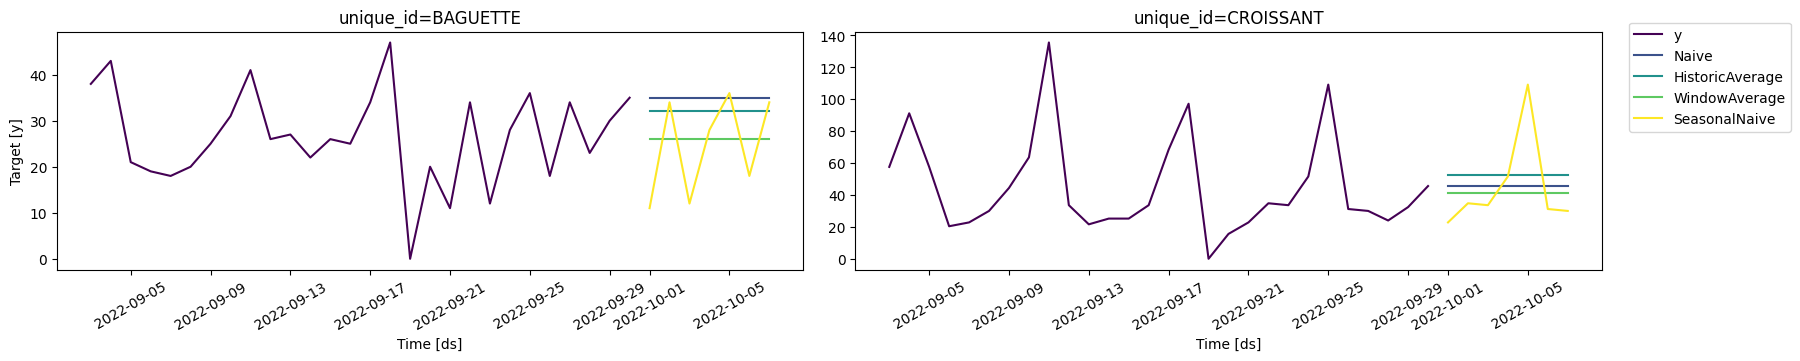

In [26]:
plot_series(
    df=df,
    forecasts_df=preds,
    ids=["BAGUETTE", "CROISSANT"],
    max_insample_length=28,
    palette="viridis"

)

In [27]:
test = df.groupby("unique_id").tail(7)
train = df.drop(test.index).reset_index(drop=True)


In [28]:
sf.fit(df=train)
preds = sf.predict(h=horizon)
eval_df = pd.merge(test , preds , 'left', ['ds', 'unique_id'])

In [29]:
evaluation = evaluate(
    eval_df,
    metrics=[mae],
)
evaluation.head()

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,12 MACARON,mae,2.857143,6.961771,3.285714,4.285714
1,BAGUETTE,mae,17.142857,5.455193,7.528571,13.142857
2,BAGUETTE APERO,mae,0.000000,0.537572,0.450000,0.000000
3,BAGUETTE GRAINE,mae,9.800000,4.612271,3.200000,3.000000
4,BANETTE,mae,1.314286,5.421984,6.571429,12.321429


In [30]:
evaluation = evaluation.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
evaluation

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,6.107556,5.228439,4.999752,7.442385


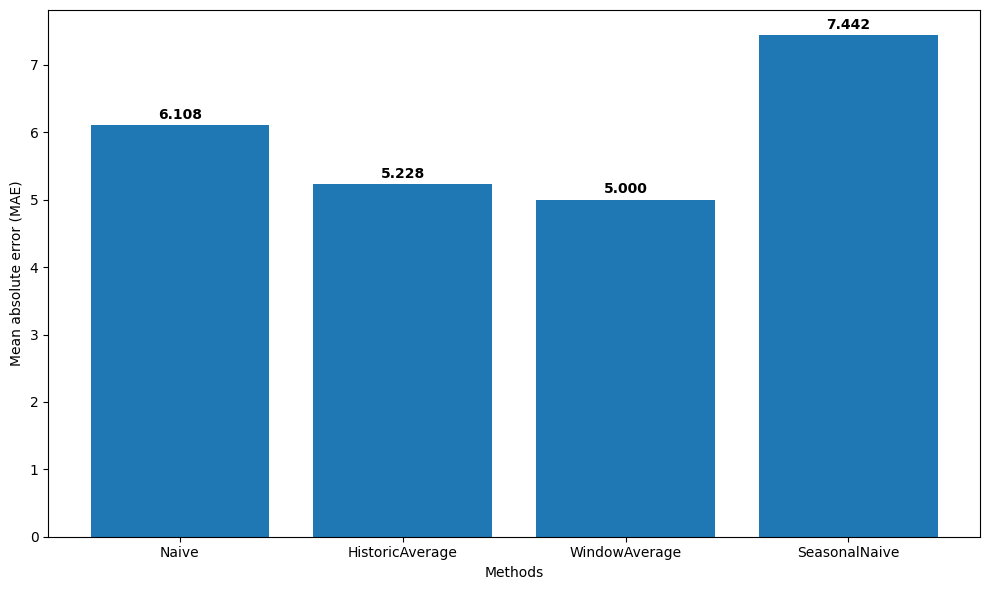

In [31]:
methods=evaluation.columns[1:].tolist()
values=evaluation.iloc[0,1:].tolist()

plt.figure(figsize=(10,6))
bars = plt.bar(methods,values)


for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
    
plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.tight_layout()

plt.show()